<a href="https://colab.research.google.com/github/darshini458/Machine-Learningprojects/blob/main/Classifying_student_performance_using_k_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
data=pd.read_csv(r"/content/student-scores.csv")
data.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [5]:
data.describe().loc[['count','mean','min','std','max']]

,id,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,1000.500000,3.665500,17.755500,83.452000,80.332000,81.336500,79.995000,79.58150,81.277500,80.888000
min,1.000000,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.00000,50.000000,60.000000
std,577.494589,2.629271,12.129604,13.224906,12.736046,12.539453,12.777895,13.72219,12.027087,11.637705
max,2000.000000,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,99.000000,100.000000


In [6]:
x=data[['weekly_self_study_hours','math_score',	'history_score',	'physics_score',	'chemistry_score',	'biology_score']].values
import sklearn
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

Text(0.5, 1.0, 'Elbow')

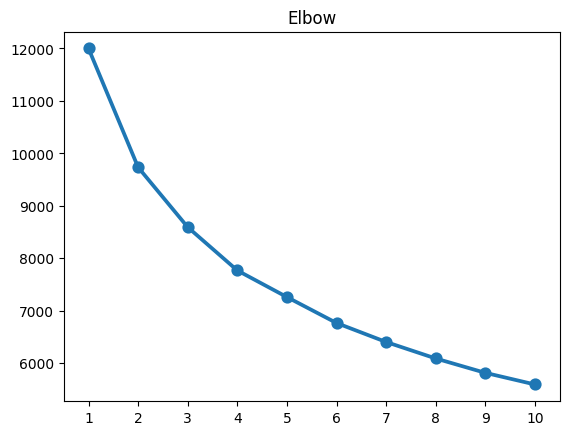

In [10]:
from sklearn.cluster import KMeans
wcss=[]
cl=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=34)
  kmeans.fit(x_scaled)
  wcss.append(kmeans.inertia_)
  cl.append(i)
sns.pointplot(x=cl,y=wcss)
plt.title("Elbow")

As we can see that there is a swift drop in the improvement when the value of k reaches 3 so the ideal value of k for this data would be 3

# New Section

In [11]:
kmeans=KMeans(n_clusters=3,init='k-means++',random_state=34)
y_kmeans=kmeans.fit_predict(x_scaled)
data['cluster']=y_kmeans
data.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score,cluster
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87,2
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90,2
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94,0
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86,1
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76,0


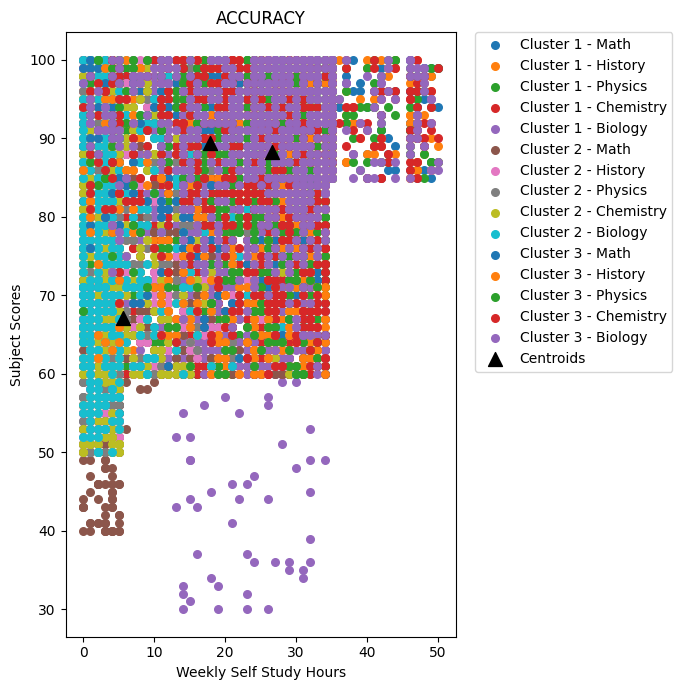

In [15]:
plt.subplots(figsize=(7, 7))

# Cluster 1
plt.scatter(data[data.cluster==0]['weekly_self_study_hours'], data[data.cluster==0]['math_score'], s=30, label='Cluster 1 - Math')
plt.scatter(data[data.cluster==0]['weekly_self_study_hours'], data[data.cluster==0]['history_score'], s=30, label='Cluster 1 - History')
plt.scatter(data[data.cluster==0]['weekly_self_study_hours'], data[data.cluster==0]['physics_score'], s=30, label='Cluster 1 - Physics')
plt.scatter(data[data.cluster==0]['weekly_self_study_hours'], data[data.cluster==0]['chemistry_score'], s=30, label='Cluster 1 - Chemistry')
plt.scatter(data[data.cluster==0]['weekly_self_study_hours'], data[data.cluster==0]['biology_score'], s=30, label='Cluster 1 - Biology')

# Cluster 2
plt.scatter(data[data.cluster==1]['weekly_self_study_hours'], data[data.cluster==1]['math_score'], s=30, label='Cluster 2 - Math')
plt.scatter(data[data.cluster==1]['weekly_self_study_hours'], data[data.cluster==1]['history_score'], s=30, label='Cluster 2 - History')
plt.scatter(data[data.cluster==1]['weekly_self_study_hours'], data[data.cluster==1]['physics_score'], s=30, label='Cluster 2 - Physics')
plt.scatter(data[data.cluster==1]['weekly_self_study_hours'], data[data.cluster==1]['chemistry_score'], s=30, label='Cluster 2 - Chemistry')
plt.scatter(data[data.cluster==1]['weekly_self_study_hours'], data[data.cluster==1]['biology_score'], s=30, label='Cluster 2 - Biology')

# Cluster 3
plt.scatter(data[data.cluster==2]['weekly_self_study_hours'], data[data.cluster==2]['math_score'], s=30, label='Cluster 3 - Math')
plt.scatter(data[data.cluster==2]['weekly_self_study_hours'], data[data.cluster==2]['history_score'], s=30, label='Cluster 3 - History')
plt.scatter(data[data.cluster==2]['weekly_self_study_hours'], data[data.cluster==2]['physics_score'], s=30, label='Cluster 3 - Physics')
plt.scatter(data[data.cluster==2]['weekly_self_study_hours'], data[data.cluster==2]['chemistry_score'], s=30, label='Cluster 3 - Chemistry')
plt.scatter(data[data.cluster==2]['weekly_self_study_hours'], data[data.cluster==2]['biology_score'], s=30, label='Cluster 3 - Biology')

# Centroids (unscale before plotting)
kmc = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(kmc[:,0], kmc[:,1], c="black", s=100, marker="^", label="Centroids")

plt.title("ACCURACY")
plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Subject Scores")
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.tight_layout()
plt.show()


In [17]:
clusters=data.groupby('cluster')
cldata=clusters[['weekly_self_study_hours','math_score',	'history_score',	'physics_score',	'chemistry_score',	'biology_score']].mean()
cldata

,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score
cluster,,,,,,
0,17.808717,89.340194,81.556901,77.960048,75.989104,72.139225
1,5.605634,67.104628,72.559356,78.187123,76.358149,77.816901
2,26.610044,88.268833,84.543575,87.768095,87.552437,89.957164
